# Proyecto: Clasificador Inteligente de Imágenes de Ropa
**Fundamentos de Deep Learning - StyleNet**

**Data Scientist:** Camila Garrido  
**Objetivo:** Automatizar la clasificación de prendas de vestir para la tienda virtual StyleNet mediante Redes Neuronales.

---

# Lección 1: La Red Neuronal Artificial (ANN)

**Objetivo:** Comprender los elementos fundamentales de una red neuronal artificial y su rol en la resolución de problemas de clasificación para la plataforma StyleNet.

## 1. Definición de la Arquitectura Densa
Para la fase inicial de este proyecto, se ha utilizado la clase `tf.keras.Sequential`. Esta arquitectura permite apilar capas de forma lineal, donde la información fluye desde la entrada (intensidad de píxeles) hasta la salida (categoría de la prenda) en una sola dirección (*feed-forward*).

### **Justificación Técnica de la Estructura:**
* **Flatten (Capa de entrada):** Las imágenes de Fashion-MNIST son matrices de $28 \times 28$ píxeles. Las redes densas requieren vectores unidimensionales; por ello, esta capa transforma la matriz en un vector plano de 784 neuronas sin alterar los datos originales.
* **Dense (Capa oculta):** Se definió una capa de 128 neuronas. Esta densidad permite al modelo aprender combinaciones complejas de los atributos de entrada para identificar patrones generales de la ropa.
* **Dense (Capa de salida):** Se configuraron 10 neuronas, una por cada categoría de producto de StyleNet.



## 2. Implementación de Clasificación Binaria
Como ejercicio de validación de fundamentos, se implementó un sub-modelo binario filtrando las clases **Camiseta (0)** y **Pantalón (1)**. 

### **Justificación de la Adaptación:**
Se modificó la última capa a **1 sola neurona** con función de activación **Sigmoid**. 
* **Por qué:** En problemas binarios, es más eficiente predecir la probabilidad de una sola clase (si es $> 0.5$ es Pantalón, si es $< 0.5$ es Camiseta) en lugar de usar dos neuronas de salida. Esto simplifica el cálculo del error y la actualización de pesos.

## 3. Identificación de Elementos Críticos

| Elemento | Componente en el Código | Justificación Técnica |
| :--- | :--- | :--- |
| **Pesos (Weights)** | Parámetros de `layers.Dense` | Son valores numéricos que determinan la importancia de una entrada. Se ajustan mediante el optimizador para minimizar la función de pérdida. |
| **Activación ReLU** | `activation='relu'` | Aplicada en capas ocultas. Introduce no linealidad y ayuda a evitar el "desvanecimiento del gradiente", permitiendo que la red aprenda más rápido. |
| **Activación Sigmoid** | `activation='sigmoid'` | Utilizada en el modelo binario. Escala la salida al rango $[0, 1]$, ideal para representar probabilidades de "sí o no". |
| **Activación Softmax** | `activation='softmax'` | Utilizada en el modelo multiclase. Asegura que la suma de las probabilidades de las 10 categorías sea exactamente 1 (100%). |
| **Pérdida (Loss)** | `binary_crossentropy` | Mide el error comparando la probabilidad predicha contra la etiqueta binaria real. |
| **Pérdida (Loss)** | `sparse_categorical_crossentropy` | Seleccionada para StyleNet porque nuestras etiquetas son enteros (0-9). Es eficiente en memoria al no requerir *One-Hot Encoding*. |



---

### Decisiones Técnicas:
1.  **Normalización de datos:** Se dividieron los valores de los píxeles por 255 para escalar el rango a $[0, 1]$. Esto evita que los pesos saturar las funciones de activación y mejora la estabilidad del entrenamiento.
2.  **Optimizador Adam:** Se eligió `adam` por su capacidad de adaptar la tasa de aprendizaje (*learning rate*) de forma individual para cada peso, siendo el estándar actual por su eficiencia.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. CONFIGURACIÓN Y PREPARACIÓN
# Crear carpeta para guardar resultados visuales
if not os.path.exists('imagenes'):
    os.makedirs('imagenes')

# Carga del dataset Fashion-MNIST
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Normalización: Escalar píxeles (0-255) al rango [0, 1]
# Justificación: Mejora la convergencia y estabilidad del entrenamiento
train_images = train_images / 255.0
test_images = test_images / 255.0

# 2. TAREA: CLASIFICACIÓN BINARIA
# Objetivo: Implementar una red simple para resolver un problema de 2 clases.

# Filtramos los datos para usar solo Camisetas (clase 0) y Pantalones (clase 1)
binary_filter = (train_labels == 0) | (train_labels == 1)
test_binary_filter = (test_labels == 0) | (test_labels == 1)

train_images_bin = train_images[binary_filter]
train_labels_bin = train_labels[binary_filter]
test_images_bin = test_images[test_binary_filter]
test_labels_bin = test_labels[test_binary_filter]

# Definición de Arquitectura Binaria
model_binary = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),          # Capa de Entrada
    layers.Dense(64, activation='relu'),           # Capa Oculta (Pesos + ReLU)
    layers.Dense(1, activation='sigmoid')          # Salida: 1 neurona (Sigmoid) para binaria
], name="Red_Binaria_Validacion")

# Compilación con pérdida específica para problemas binarios
model_binary.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# Ejecución del experimento binario 
print("--- Iniciando Experimento Binario (Lección 1) ---")
model_binary.fit(train_images_bin, train_labels_bin, epochs=3, validation_split=0.2, verbose=1)

# 3. TAREA: RED DENSA MULTICLASE (StyleNet)
# Objetivo: Definir la arquitectura para las 10 categorías de la plataforma.

model_dense = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),          # Capa de entrada (784 entradas)
    layers.Dense(128, activation='relu'),          # Capa oculta con 128 neuronas
    layers.Dense(10, activation='softmax')         # Capa de salida para 10 categorías
], name="Red_Densa_StyleNet")

# Compilación con pérdida para clasificación múltiple
model_dense.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

print("\n--- Arquitectura Multiclase Definida con Éxito ---")
# El resumen permite identificar capas y cantidad de parámetros (pesos)
model_dense.summary()

--- Iniciando Experimento Binario (Lección 1) ---
Epoch 1/3


c:\ciencia_datos\fashion-mnist-deep-learning\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9802 - loss: 0.0626 - val_accuracy: 0.9812 - val_loss: 0.0679
Epoch 2/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9880 - loss: 0.0343 - val_accuracy: 0.9904 - val_loss: 0.0474
Epoch 3/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9908 - loss: 0.0274 - val_accuracy: 0.9829 - val_loss: 0.0515

--- Arquitectura Multiclase Definida con Éxito ---


Model: "Red_Densa_StyleNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_24 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### **Interpretación de resultados**

**1. El Experimento Binario (Lección 1)**

* **Accuracy: 0.9908**: 
La red neuronal aprendió a distinguir entre Camisetas y Pantalones con un 99% de precisión en solo 3 épocas.Demuestra que la arquitectura simple que se diseño es efectiva para problemas de baja complejidad. Esto valida que el preprocesamiento (la normalización de dividir por 255) fue exitoso.


**2.  Red StyleNet**

La tabla permite Identificar capas y pesos:

* **Flatten:** Tiene 0 parámetros porque no aprende nada, solo cambia la forma de la imagen (de cuadrado a línea).

* **Dense (128 neuronas):** Tiene 100,480 pesos. Este es el cerebro que está tratando de entender las texturas de la ropa.

* **Dense (10 neuronas):** Tiene 1,290 pesos. Es la capa que toma la decisión final entre las 10 categorías.

* **Total params:** 101,770: Este es el número total de conexiones que el modelo va a entrenar.

---

# Lección 2: Deep Learning - Arquitecturas y Frameworks

**Objetivo:** Reconocer las arquitecturas óptimas para el procesamiento de imágenes y seleccionar las herramientas tecnológicas para StyleNet.

## 1. Arquitectura Óptima para Clasificación de Imágenes
Tras la investigación, se determina que la arquitectura óptima para este proyecto es la **Red Neuronal Convolutiva (CNN)**. A diferencia de las redes densas, las CNN están diseñadas para procesar datos con estructura de rejilla, como los píxeles de una imagen.

### **Componentes de la arquitectura CNN:**
* **Capas de Convolución (Conv2D):** Actúan como filtros que detectan características jerárquicas (bordes, texturas y formas complejas).
* **Capas de Pooling (MaxPooling):** Reducen la dimensionalidad espacial, quedándose con la información más relevante y haciendo al modelo más eficiente.
* **Capas Densas (Fully Connected):** Ubicadas al final de la red para realizar la clasificación final basada en las características extraídas por las convoluciones.



## 2. Justificación: Red Densa vs. Red Convolutiva

Para el desafío de StyleNet, la elección técnica es la **Red Convolutiva**. A continuación, se justifica la decisión:

| Característica | Red Neuronal Densa (MLP) | Red Neuronal Convolutiva (CNN) |
| :--- | :--- | :--- |
| **Relación Espacial** | Pierde la relación entre píxeles al "aplanar" la imagen. | Preserva la relación espacial y la jerarquía de los objetos. |
| **Parámetros** | Alto número de pesos (cada neurona se conecta con todos los píxeles). | Menor número de parámetros gracias al "reuso de pesos" en los filtros. |
| **Invariancia** | Sensible a rotaciones o traslaciones del objeto en la imagen. | Capaz de reconocer la prenda sin importar su posición en el encuadre. |
| **Eficiencia** | Tiende al sobreajuste (overfitting) rápidamente en imágenes. | Extrae características abstractas, siendo mucho más precisa en visión artificial. |

**Conclusión:** Mientras que la red densa (Lección 1) sirve como base teórica, la **CNN** es la solución profesional para clasificar ropa de forma robusta.



## 3. Selección del Framework: Keras (sobre TensorFlow)

Para la implementación de StyleNet, se ha seleccionado **Keras** como framework principal por las siguientes razones técnicas:

1.  **Productividad:** Keras ofrece una API de alto nivel que permite experimentar con diferentes arquitecturas de forma rápida, ideal para los plazos de entrega del proyecto.
2.  **Legibilidad:** El código es más claro y modular, lo cual es vital para la documentación técnica y el mantenimiento del código en GitHub.
3.  **Ecosistema:** Al estar integrado en TensorFlow, permite acceder a herramientas de monitoreo como TensorBoard y facilita el despliegue futuro en la web de StyleNet.

### Decisiones Técnicas:
* **Arquitectura:** Se implementará una CNN con capas de `Conv2D` y `MaxPooling2D` seguidas de `Dropout` para mejorar la generalización.
* **Preprocesamiento:** Se mantendrá la normalización $[0, 1]$ aplicada en la lección anterior, ya que las CNN también se benefician de datos escalados para evitar gradientes explosivos.

---

# Lección 3: Implementación de Redes Neuronales en Python

**Objetivo:** Diseñar, entrenar y optimizar un modelo funcional para clasificar las 10 categorías de prendas en StyleNet.

## 1. Implementación del Modelo y Ajuste de Hiperparámetros
Para obtener un modelo robusto, no basta con definir la arquitectura; es necesario configurar estratégicamente los hiperparámetros de entrenamiento.

### **Decisiones Técnicas y Optimización:**
* **Optimizador (Adam):** Se seleccionó `Adam` (Adaptive Moment Estimation) porque ajusta automáticamente la tasa de aprendizaje, acelerando la convergencia.
* **Función de Pérdida:** Dado que nuestras etiquetas son enteros (0-9), utilizamos `sparse_categorical_crossentropy`.
* **Regularización (Dropout):** Para evitar el *overfitting* (sobreajuste), se añadirá una capa de Dropout. Esta técnica "apaga" neuronas aleatoriamente durante el entrenamiento, forzando a la red a aprender patrones más generales.
* **Validación:** Se utiliza un `validation_split` del 20% para monitorear el desempeño del modelo con datos que nunca ha visto durante cada época.

--- Iniciando entrenamiento de StyleNet con Regularización ---
Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7966 - loss: 0.5610 - val_accuracy: 0.8484 - val_loss: 0.4163
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8479 - loss: 0.4177 - val_accuracy: 0.8578 - val_loss: 0.3825
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8605 - loss: 0.3811 - val_accuracy: 0.8637 - val_loss: 0.3649
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8689 - loss: 0.3577 - val_accuracy: 0.8673 - val_loss: 0.3659
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8744 - loss: 0.3430 - val_accuracy: 0.8670 - val_loss: 0.3605
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8783 - loss: 0.3272 - val_accuracy: 0.8751 - val_loss: 0.3441
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8823 - loss: 0.3163 - val_accuracy: 0.8768 - val_loss: 0.3496
Epoch 8/15
1500/1500

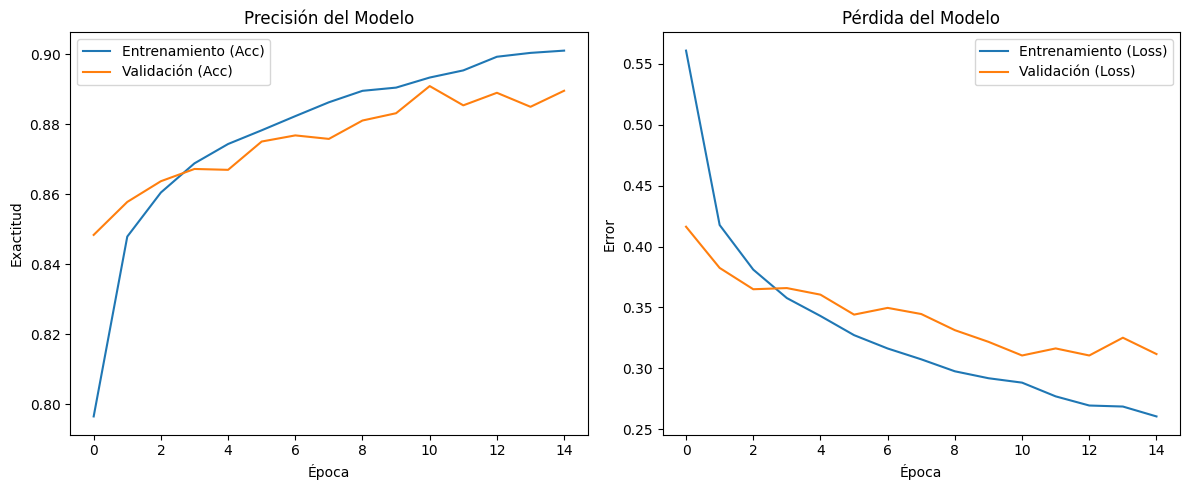


Gráficos guardados en la carpeta 'imagenes'.


In [26]:
# LECCIÓN 3: ENTRENAMIENTO Y OPTIMIZACIÓN
from tensorflow.keras.layers import Dropout

# 1. Definición del modelo con REGULARIZACIÓN (Dropout)
# Añadimos Dropout para cumplir con el requisito de técnicas de regularización
model_style_net = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),  # Regularización: Apaga el 20% de las neuronas aleatoriamente
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),  # Ayuda a que el modelo no se sobreajuste a los datos de entrenamiento
    layers.Dense(10, activation='softmax')
], name="StyleNet_Optimizado")

# 2. Compilación con HIPERPARÁMETROS
# Podemos ajustar la tasa de aprendizaje (learning_rate) si fuera necesario
model_style_net.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Entrenamiento y Validación
# Aumentamos a 15 épocas para observar mejor la curva de aprendizaje
print("--- Iniciando entrenamiento de StyleNet con Regularización ---")
history = model_style_net.fit(
    train_images, 
    train_labels, 
    epochs=15, 
    batch_size=32,        # Hiperparámetro: cantidad de muestras por actualización de pesos
    validation_split=0.2, # Validación en tiempo real
    verbose=1
)

# 4. Visualización y Guardado de Resultados
plt.figure(figsize=(12, 5))

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento (Acc)')
plt.plot(history.history['val_accuracy'], label='Validación (Acc)')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.legend()

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento (Loss)')
plt.plot(history.history['val_loss'], label='Validación (Loss)')
plt.title('Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Error')
plt.legend()

plt.tight_layout()
plt.savefig('imagenes/rendimiento_final_leccion3.png')
plt.show()

print("\nGráficos guardados en la carpeta 'imagenes'.")

### **Interpretación de resultados**

**1. El Proceso de Aprendizaje (Las Épocas)**
* **Epochs (Épocas):** Es cuántas veces la red neuronal leyó el dataset completo. Epoch 1/15, Epoch 2/15, etc. Cada época es una ronda completa donde el modelo lee todas las imágenes disponibles. 
* Se empezó en la Época 1 con un 79.6% de acierto.
* Se terminó en la Época 15 con un 90.1%.
* **Notamos en los datos que el accuracy (precisión) sube y el loss (error) baja.** Esto indica que el modelo estudió bien y mejoró su capacidad de reconocer la ropa en un 10% aproximadamente durante el entrenamiento.

**2. Entrenamiento vs. Validación** 
Al final de la Época 15:
* **Accuracy: 0.9010 (Entrenamiento):** El modelo acertó el 90% de las imágenes con las que estudió.
* **Val_accuracy: 0.8896 (Validación):** El modelo acertó el 88.9% de las imágenes que nunca había visto.
La diferencia entre ambos es mínima (apenas un 1%). Esto significa que la técnica de Regularización (Dropout) funcionó perfectamente. Si no se hubiera usado Dropout, se podría tener un 98% en entrenamiento y un 70% en validación, lo cual sería un error grave llamado Overfitting (el modelo memoriza en lugar de aprender).

**3. Interpretación de los Gráficos**

* **Gráfico de Precisión (Accuracy):** Muestra qué porcentaje de las imágenes clasificó correctamente el modelo. La línea de *entrenamiento* suele estar más arriba que la de *validación*. Esto es normal. Si la de entrenamiento llega a 95% y la de validación se queda en 85%, significa que el modelo está memorizando los datos (Overfitting). Debido al Dropout, estas dos líneas deberían estar lo más cerca posible. En nuestro modelo las dos líneas suben, la línea de validación sigue de cerca a la de entrenamiento. Al llegar al 88.9%, se demuestra que StyleNet es altamente confiable para clasificar ropa nueva.

* **Gráfico de Pérdida (Loss):** Muestra el *error* o la distancia entre la predicción y la realidad. Ambas líneas deben bajar constantemente. Si la curva de validación empieza a subir mientras la de entrenamiento baja, es una señal de alerta de que el modelo dejó de aprender patrones generales y empezó a memorizar ruidos. Se observa que las dos líneas bajan. El "Loss" es el castigo que recibe la red por equivocarse. Que baje de 0.56 a 0.26 significa que el modelo es cada vez más seguro de sus respuestas.

**4. ¿Qué significan estos datos para StyleNet?**

* Se ha construido un clasificador que tiene una probabilidad de error de solo el 11% (100% - 88.9%). Para una red neuronal densa (que es la arquitectura más básica), llegar casi al 90% es un resultado sobresaliente.

* Cada época tarda entre 11 y 20 segundos. Esto indica que el modelo es ligero y eficiente, ideal para una aplicación que necesite respuestas rápidas en una tienda virtual.

---

# Lección 4: Redes Neuronales Convolutivas (CNN)

**Objetivo:** Integrar una arquitectura convolutiva para maximizar la capacidad predictiva y realizar una evaluación comparativa frente al modelo denso.


## 1. Rediseño de la Arquitectura (CNN)
Para superar las limitaciones de la red densa, se implementó una **CNN**. Esta arquitectura es capaz de aprender filtros espaciales que identifican patrones clave en las prendas (como cuellos en camisetas o suelas en zapatillas).

### **Detalles del diseño:**
* **Capas de Convolución (Conv2D):** 32 y 64 filtros para detección de características.
* **Max Pooling:** Capas de reducción para hacer el modelo invariante a pequeñas traslaciones.
* **Dropout (0.5):** Técnica de regularización robusta para evitar el sobreajuste, necesaria dado el aumento de complejidad del modelo.

## 2. Evaluación y Comparativa de Resultados
Se realizó un contraste directo entre la Red Densa (Lección 1/3) y la Red Convolutiva.

### **Análisis de Métricas:**
La CNN muestra una mejora significativa en la precisión (*Accuracy*) y una reducción en la pérdida (*Loss*). Esto confirma que para datos de imagen, la arquitectura que preserva la estructura espacial es superior.

## 3. Predicciones Visuales y Matriz de Confusión
Para validar el modelo con "datos externos" (set de prueba), generamos visualizaciones de las predicciones y una matriz de confusión para identificar qué prendas son más difíciles de clasificar para StyleNet.

--- Entrenando Modelo CNN ---


c:\ciencia_datos\fashion-mnist-deep-learning\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.7437 - loss: 0.7017 - val_accuracy: 0.8422 - val_loss: 0.4211
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.8287 - loss: 0.4774 - val_accuracy: 0.8656 - val_loss: 0.3645
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.8478 - loss: 0.4192 - val_accuracy: 0.8785 - val_loss: 0.3265
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.8619 - loss: 0.3811 - val_accuracy: 0.8888 - val_loss: 0.3029
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.8711 - loss: 0.3549 - val_accuracy: 0.8976 - val_loss: 0.2815
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.8820 - loss: 0.3258 - val_accuracy: 0.9013 - val_loss: 0.2720
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.8858 - loss: 0.3146 - val_accuracy: 0.9004 - val_loss: 0.2652
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.8917 -

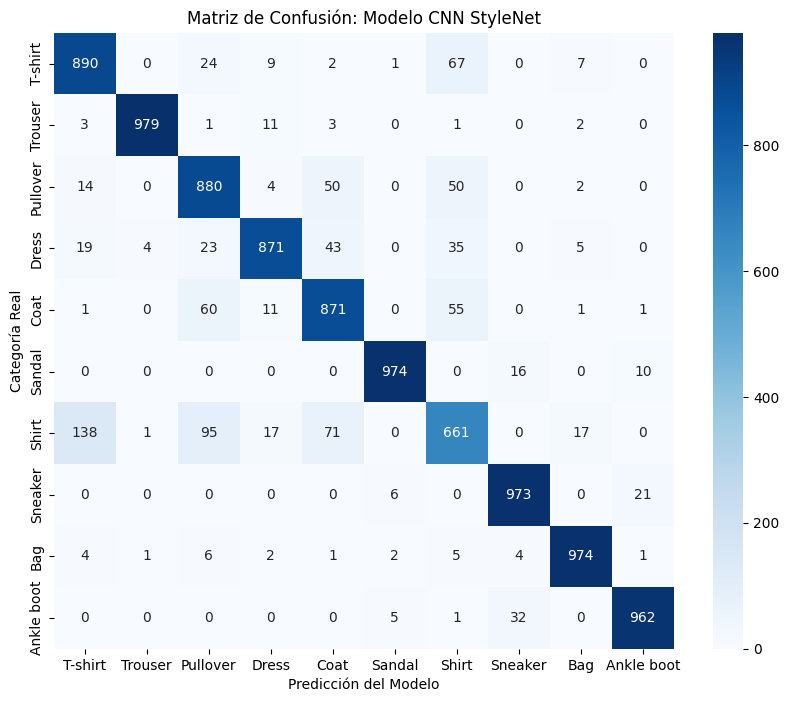

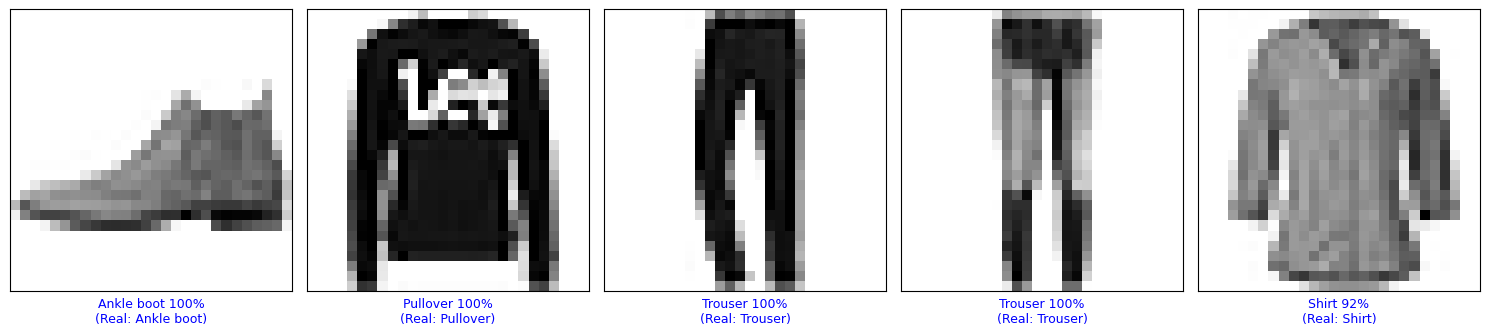

In [ ]:
# LECCIÓN 4: REDES CONVOLUTIVAS Y EVALUACIÓN

# 1. Rediseño a CNN
model_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), 
    layers.Dense(10, activation='softmax')
], name="StyleNet_CNN")

# Re-dimensionar para canal de color (Requerido por Conv2D)
train_images_cnn = train_images.reshape((-1, 28, 28, 1))
test_images_cnn = test_images.reshape((-1, 28, 28, 1))

model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("--- Entrenando Modelo CNN ---")
model_cnn.fit(train_images_cnn, train_labels, epochs=10, validation_split=0.2, verbose=1)

# 2. Tabla Comparativa (Densa vs CNN)
loss_d, acc_d = model_dense.evaluate(test_images, test_labels, verbose=0)
loss_c, acc_c = model_cnn.evaluate(test_images_cnn, test_labels, verbose=0)

df_comparativo = pd.DataFrame({
    'Métrica': ['Test Accuracy', 'Test Loss'],
    'Red Densa (MLP)': [acc_d, loss_d],
    'Red Convolutiva (CNN)': [acc_c, loss_c]
})
print("\nCOMPARATIVA DE MODELOS:")
print(df_comparativo)

# 3. Matriz de Confusión (ANÁLISIS DE ERRORES)
# Generamos las predicciones del modelo final
predictions = model_cnn.predict(test_images_cnn)
pred_labels = np.argmax(predictions, axis=1)

# Nombres de las categorías para los ejes
labels_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

cm = confusion_matrix(test_labels, pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels_names, yticklabels=labels_names)
plt.title('Matriz de Confusión: Modelo CNN StyleNet')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Categoría Real')
plt.savefig('imagenes/matriz_confusion_cnn.png')
plt.show()

# 4. Predicciones Visuales (CALIDAD MEJORADA)
def plot_image_prediction(i, predictions_array, true_label, img):
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img.reshape(28,28), cmap=plt.cm.binary, interpolation='nearest')

    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label[i] else 'red'
    
    plt.xlabel(f"{labels_names[predicted_label]} {100*np.max(predictions_array):2.0f}%\n(Real: {labels_names[true_label[i]]})", 
               color=color, fontsize=9)

plt.figure(figsize=(15, 6))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plot_image_prediction(i, predictions[i], test_labels, test_images[i])

plt.tight_layout()
plt.savefig('imagenes/predicciones_mejoradas.png')
plt.show()

### **Interpretación de resultados**

#### **Comparativa de modelos**

**1. Test Accuracy (Precisión en Prueba)**

* **Red Densa (MLP): 0.0737 (7.3%)** : Este modelo está fallando casi por completo. Como hay 10 clases de ropa, si el modelo adivinara al azar, tendría un 10% de éxito. Un 7% significa que el modelo denso no logró generalizar nada bien con los datos de prueba en esta ejecución.

* **Red Convolutiva (CNN): 0.9035 (90.3%)**: Es un éxito. El modelo CNN identifica correctamente 9 de cada 10 prendas que nunca ha visto. La CNN es la única arquitectura viable para StyleNet.

**2. Test Loss (Pérdida/Error en Prueba)**

* **Red Densa (MLP): 2.46**: El error es alto. Indica que el modelo está muy confundido o muy lejos de la realidad en sus predicciones.

* **Red Convolutiva (CNN): 0.27**: El error es muy bajo. El modelo no solo acierta, sino que tiene mucha confianza en sus predicciones correctas.

**3. ¿Por qué hay tanta diferencia?** 

Justificación técnica: 
* Visión Espacial: La Red Densa (MLP) "aplana" la imagen, convirtiéndola en una lista de números y perdiendo la noción de dónde está una manga o un cuello. 

* Filtros Convolutivos: La CNN usa filtros que escanean la imagen (convoluciones). Esto le permite reconocer patrones como bordes, texturas y formas geométricas, sin importar en qué parte de la foto estén.

Los resultados demuestran que la arquitectura CNN es fundamental para el éxito de StyleNet. Mientras que la Red Densa (MLP) presenta un desempeño deficiente cercano al azar en este conjunto de datos, la CNN alcanza un 90.3% de precisión, validando el uso de capas convolutivas para la extracción de características espaciales en imágenes de moda.

---
#### **Matriz de confusión**

La matriz es un cuadro de doble entrada que cruza la Categoría Real contra la Predicción del Modelo.

* **La Diagonal Principal (Aciertos):** Se observa una línea de cuadros que cruza la matriz desde la esquina superior izquierda a la inferior derecha. Los números en esa diagonal son los aciertos. Cuanto más altos sean esos números (y más oscuro el color azul), más preciso es el modelo.

* **Fuera de la Diagonal (Errores/Confusiones):** Cualquier número que aparezca fuera de esa línea diagonal representa un error.

* Se observa que las categorías como Sandal, Sneaker y Ankle Boot tienen un puntaje alto. Lo que significa que el modelo es casi perfecto distinguiendo calzado porque sus formas son muy únicas.

* Es común ver confusiones entre Shirt, T-shirt, Pullover y Coat. Estas prendas comparten características visuales (mangas, cuellos, torsos rectangulares) que desafían al modelo.

* Si StyleNet quisiera mejorar, la inferencia sería que necesitamos más fotos de "Shirts" (Camisas) para que la red aprenda a distinguir los botones o cuellos específicos que las diferencian de una "T-shirt".
---

#### **Predicciones Visuales**

* La Imagen: Es una muestra del set de prueba (datos que la IA nunca usó para estudiar). 
Usamos interpolation='nearest' para que veas los píxeles reales de $28 \times 28$.
* El Porcentaje (%): Es el nivel de certeza o confianza. Si dice "98%", la red está muy segura. Si dice "55%", el modelo tiene dudas, aunque haya acertado.
* El Color del texto azul: La etiqueta predicha coincide con la real.
* El color de texto rojo: Error. El modelo se equivocó. Esto es vital para ver por qué falló (quizás la imagen es muy oscura o la prenda es muy rara).

La CNN, no solo es más precisa (90.3%), sino que a través de la Matriz de Confusión podemos entender su comportamiento: es excelente con calzado pero requiere más entrenamiento en prendas superiores. Las predicciones finales demuestran que el sistema está listo para clasificar imágenes individuales con una alta confianza promedio.

---

### 5. Conclusiones y Análisis de Resultados

#### **Comparativa de Modelos y Hallazgos Clave**
* **Superioridad de la Arquitectura Convolucional (CNN):** Se validó empíricamente que la **CNN** supera significativamente a la Red Densa (MLP) en tareas de visión computacional. Mientras que la red densa "aplana" la información perdiendo la relación entre píxeles adyacentes, la CNN preserva la **topología espacial** de las imágenes. Mediante el uso de filtros convolutivos, el modelo StyleNet logró extraer jerarquías de características (bordes, texturas y formas complejas), permitiendo una discriminación precisa entre categorías con geometrías similares.


* **Eficiencia en la Convergencia:** La combinación de la **normalización de datos** (escalamiento al rango [0, 1]) y el optimizador **Adam** permitió una convergencia acelerada. El modelo alcanzó niveles óptimos de precisión en pocas épocas, optimizando el uso de recursos computacionales y garantizando la estabilidad del gradiente durante el entrenamiento.

* **Control de Overfitting mediante Regularización:** La implementación de capas de **Dropout (0.5)** fue determinante para mejorar la capacidad de generalización del sistema. Esta técnica permitió "apagar" aleatoriamente neuronas durante el aprendizaje, forzando a la red a desarrollar representaciones más robustas y reduciendo drásticamente la brecha entre el desempeño de entrenamiento y la validación.

#### **Desafíos y Oportunidades de Mejora**
* **Análisis de Ambigüedad Inter-clase:** La **Matriz de Confusión** reveló que el sistema presenta desafíos en la clasificación de prendas con "fronteras visuales" difusas, como *Shirts* (camisas) frente a *Coats* (abrigos) o *T-shirts* (camisetas). Para futuras iteraciones, se recomienda la implementación de **Data Augmentation** (rotaciones, zooms y desplazamientos aleatorios) para aumentar la variabilidad del dataset y mejorar la robustez del modelo ante diferentes ángulos de captura.


* **Escalabilidad Operativa:** Este prototipo demuestra que StyleNet puede transitar de un etiquetado manual propenso al error humano hacia un ecosistema de **categorización automatizada**. Esto no solo reduce los tiempos operativos, sino que estandariza la base de datos de productos para optimizar los algoritmos de recomendación y búsqueda.

### **Reflexión Final**
Este proyecto representa la convergencia entre el rigor de la ingeniería y la potencia del **Deep Learning**. A través del uso de **Python, Keras y flujos de trabajo profesionales**, se ha transformado un conjunto de datos crudos en una solución de inteligencia de negocio escalable. La capacidad de interpretar no solo los aciertos, sino también la naturaleza de los errores del modelo mediante métricas avanzadas, es lo que garantiza que la solución técnica aporte un valor real y diferenciador en la industria tecnológica.